##Problem Statement
Implement a simple feedforward neural network from scratch in Python without using any built-in deep learning libraries. This implementation will focus on basic components like ,

*   Forward pass
*   Backward propagation (backpropagation)

and training using gradient descent.

This notebook implements a simple two-layer Neural
Network from scratch to classify handwritten digits from the MNIST dataset. It covers data loading, preprocessing, model definition, training, and evaluation.

First, we import the necessary libraries: NumPy for numerical operations, Pandas for data manipulation, Matplotlib for plotting, and `mnist` from Keras datasets to load the MNIST data.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

We load the MNIST training and testing datasets using `mnist.load_data()`. Then, we print the shapes of the training images (`X_train`), training labels (`y_train`), testing images (`X_test`), and testing labels (`y_test`) to understand their dimensions.

In [ ]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing data shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)


This cell visualizes the first 10 training images along with their corresponding labels to get a sense of the dataset. `matplotlib.pyplot.imshow` is used to display the grayscale images.

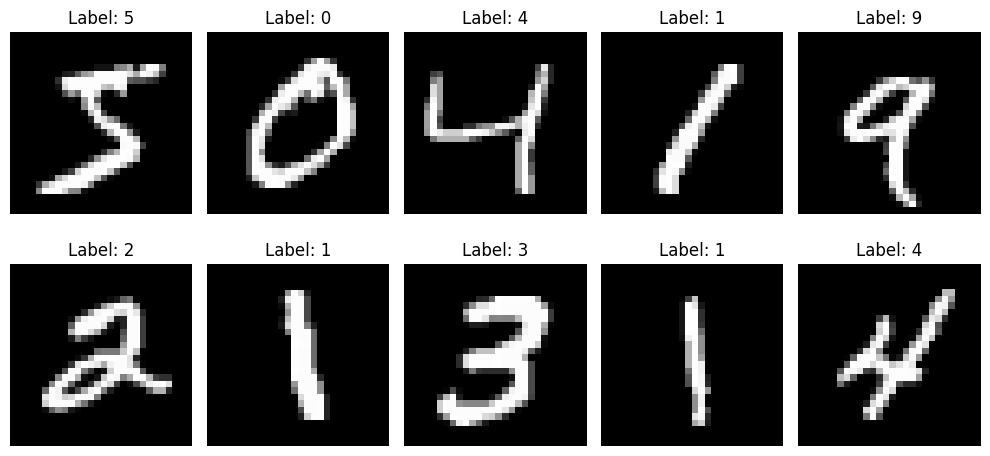

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Here, we display key statistics about the dataset, such as the number of training and testing images, image dimensions (height and width), and the unique classes present in the labels, along with a list of those classes.

In [ ]:
print("Number of training images:", len(X_train))
print("Number of testing images:", len(X_test))

print("Image height:", X_train.shape[1])
print("Image width:", X_train.shape[2])

print("Number of classes:", len(np.unique(y_train)))

print("\nClasses:")
print(np.unique(y_train))

Number of training images: 60000
Number of testing images: 10000
Image height: 28
Image width: 28
Number of classes: 10

Classes:
[0 1 2 3 4 5 6 7 8 9]


This cell calculates and displays the distribution of each digit (0-9) in the training dataset. This helps in understanding if the dataset is balanced or if certain digits are over/under-represented.

In [ ]:
unique, counts = np.unique(y_train, return_counts=True)

class_distribution = pd.DataFrame({
    "Digit": unique,
    "Number of Images": counts
})

class_distribution

,Digit,Number of Images
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


Before feeding the images to the neural network, we normalize the pixel values. Images are initially represented with pixel values between 0 and 255. We convert them to `float32` and scale them down to the range [0, 1] by dividing by 255.0. This helps in faster and more stable training.

In [ ]:
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


The 2D image data (28x28 pixels) is reshaped into a 1D vector of 784 pixels for each image. This is a common practice for fully connected neural networks, where each pixel acts as an input feature. We then print the new shapes of the training and testing data.

In [ ]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (60000, 784)
Testing data shape: (10000, 784)


To speed up training during development, we limit the training set to the first 10,000 samples. This allows for quicker iteration and testing of the model architecture and training process.

In [ ]:
# Number of samples used for training
num_train_samples = 10000

X_train_small = X_train[:num_train_samples]
y_train_small = y_train[:num_train_samples]

print("Training samples used:", X_train_small.shape[0])

Training samples used: 10000


This cell defines the architecture of our neural network: the number of input neurons (784, corresponding to the 28x28 image pixels), the number of neurons in the hidden layer (128), and the number of output neurons (10, for the 10 digits 0-9).

In [ ]:
input_size = 784
hidden_size = 128
output_size = 10

print("Input neurons:", input_size)
print("Hidden neurons:", hidden_size)
print("Output neurons:", output_size)

Input neurons: 784
Hidden neurons: 128
Output neurons: 10


This function implements the Rectified Linear Unit (ReLU) activation function, which is commonly used in hidden layers of neural networks. It returns `z` if `z > 0`, and `0` otherwise.

In [ ]:
def relu(z):
    return np.maximum(0, z)

This function calculates the derivative of the ReLU activation function, which is needed during backpropagation. The derivative is `1` for `z > 0` and `0` for `z <= 0`.

In [ ]:
def relu_derivative(z):
    return (z > 0).astype(float)

This function implements the Softmax activation function, typically used in the output layer of a multi-class classification neural network. It converts a vector of arbitrary real values into a probability distribution, where each value is between 0 and 1, and all values sum to 1. Numerical stability is handled to prevent overflow/underflow issues.

In [ ]:
def softmax(z):
    # Numerical stability
    z = z - np.max(z, axis=1, keepdims=True)

    exp_values = np.exp(z)

    probabilities = exp_values / np.sum(
        exp_values,
        axis=1,
        keepdims=True
    )

    return probabilities

This function converts integer labels into a one-hot encoded format. For example, if `num_classes` is 10 and a label is `3`, it will be converted to an array `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`. This representation is required for training with cross-entropy loss.

In [ ]:
def one_hot_encode(y, num_classes):

    one_hot = np.zeros(
        (len(y), num_classes)
    )

    one_hot[
        np.arange(len(y)),
        y
    ] = 1

    return one_hot

We apply the `one_hot_encode` function to both the small training labels (`y_train_small`) and the full test labels (`y_test`). This transforms the integer labels into a binary vector format suitable for training the neural network. The first 10 original and one-hot encoded labels are printed for verification.

In [ ]:
y_train_one_hot = one_hot_encode(
    y_train_small,
    output_size
)

y_test_one_hot = one_hot_encode(
    y_test,
    output_size
)

print("Original labels:")
print(y_train_small[:10])

print("\nOne-hot encoded labels:")
print(y_train_one_hot[:10])

Original labels:
[5 0 4 1 9 2 1 3 1 4]

One-hot encoded labels:
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


This function computes the cross-entropy loss, which is a standard loss function for multi-class classification problems. It measures the performance of a classification model whose output is a probability value between 0 and 1. A small epsilon is added to `y_pred` to prevent taking the logarithm of zero.

In [ ]:
def cross_entropy_loss(y_true, y_pred):

    epsilon = 1e-12

    # Prevent log(0)
    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    loss = -np.mean(
        np.sum(
            y_true * np.log(y_pred),
            axis=1
        )
    )

    return loss

Here, we initialize the weights (`W1`, `W2`) and biases (`b1`, `b2`) for our two-layer neural network. Weights are initialized using a He initialization scheme (`np.sqrt(2 / input_size)`) to help with vanishing/exploding gradients in ReLU networks, while biases are initialized to zeros. The shapes of the initialized parameters are printed to confirm their dimensions.

In [ ]:
np.random.seed(42)

# First layer
W1 = np.random.randn(
    input_size,
    hidden_size
) * np.sqrt(2 / input_size)

b1 = np.zeros(
    (1, hidden_size)
)

# Second layer
W2 = np.random.randn(
    hidden_size,
    output_size
) * np.sqrt(2 / hidden_size)

b2 = np.zeros(
    (1, output_size)
)

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)

print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (784, 128)
b1 shape: (1, 128)
W2 shape: (128, 10)
b2 shape: (1, 10)


This function performs the forward pass through the neural network. It takes the input `X` and the network parameters (weights and biases) and calculates the output probabilities. It involves a matrix multiplication and addition for the hidden layer (`Z1`), followed by the ReLU activation (`A1`), and then another matrix multiplication and addition for the output layer (`Z2`), ending with the Softmax activation (`A2`).

In [ ]:
def forward_pass(X, W1, b1, W2, b2):

    # Hidden layer
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    # Output layer
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

To verify the forward pass, we run a small batch of 100 samples from `X_train_small` through the `forward_pass` function. We then print the shapes of the intermediate outputs (`Z1`, `A1`, `Z2`, `A2`) to ensure they match our expected network architecture.

In [ ]:
Z1, A1, Z2, A2 = forward_pass(
    X_train_small[:100],
    W1,
    b1,
    W2,
    b2
)

print("Z1 shape:", Z1.shape)
print("A1 shape:", A1.shape)
print("Z2 shape:", Z2.shape)
print("A2 shape:", A2.shape)

Z1 shape: (100, 128)
A1 shape: (100, 128)
Z2 shape: (100, 10)
A2 shape: (100, 10)


This cell displays the predicted probabilities for the first image in the sample batch after the forward pass. It also confirms that the sum of these probabilities is approximately 1, as expected from the Softmax activation.

In [ ]:
print("Probabilities for first image:")

print(A2[0])

print("\nSum of probabilities:")

print(np.sum(A2[0]))

Probabilities for first image:
[0.14479961 0.0925005  0.09725679 0.04483728 0.06972212 0.13210605
 0.0556922  0.14834432 0.07805109 0.13669003]

Sum of probabilities:
0.9999999999999999


This function implements the backpropagation algorithm, which calculates the gradients of the loss function with respect to the network's weights and biases. These gradients are crucial for updating the parameters during training. It computes `dZ2`, `dW2`, `db2`, `dA1`, `dZ1`, `dW1`, and `db1` in reverse order of the forward pass.

In [ ]:
def backward_pass(
    X,
    y_true,
    Z1,
    A1,
    Z2,
    A2,
    W2
):

    m = X.shape[0]

    # -------------------------
    # Output Layer
    # -------------------------

    dZ2 = A2 - y_true

    dW2 = np.dot(
        A1.T,
        dZ2
    ) / m

    db2 = np.sum(
        dZ2,
        axis=0,
        keepdims=True
    ) / m

    # -------------------------
    # Hidden Layer
    # -------------------------

    dA1 = np.dot(
        dZ2,
        W2.T
    )

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(
        X.T,
        dZ1
    ) / m

    db1 = np.sum(
        dZ1,
        axis=0,
        keepdims=True
    ) / m

    return dW1, db1, dW2, db2

This `predict` function takes input data `X` and the trained network parameters to make predictions. It performs a forward pass to get the class probabilities and then uses `np.argmax` to select the class with the highest probability as the final prediction.

In [ ]:
def predict(X, W1, b1, W2, b2):

    _, _, _, probabilities = forward_pass(
        X,
        W1,
        b1,
        W2,
        b2
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    return predictions

This simple utility function calculates the accuracy of the model by comparing the true labels (`y_true`) with the predicted labels (`y_pred`). It returns the mean of the correctly classified samples.

In [ ]:
def accuracy(y_true, y_pred):

    return np.mean(
        y_true == y_pred
    )

We define the hyperparameters for training: `learning_rate` controls the step size during gradient descent, `epochs` is the number of full passes through the training dataset, and `batch_size` determines the number of samples processed before updating model parameters. These values are printed for clarity.

In [ ]:
learning_rate = 0.01
epochs = 20
batch_size = 64

loss_history = []
accuracy_history = []

print("Learning Rate:", learning_rate)
print("Epochs:", epochs)
print("Batch Size:", batch_size)

Learning Rate: 0.01
Epochs: 20
Batch Size: 64


This is the main training loop for the neural network. It iterates over a specified number of `epochs`. In each epoch, the training data is shuffled and split into mini-batches. For each batch, a forward pass is performed, the loss is calculated, backpropagation computes the gradients, and then the weights and biases are updated using gradient descent. The epoch loss and training accuracy are tracked and printed after each epoch.

In [ ]:
num_samples = X_train_small.shape[0]

for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(num_samples)

    X_shuffled = X_train_small[indices]
    y_shuffled = y_train_one_hot[indices]

    epoch_loss = 0
    num_batches = 0

    # Mini-batch training
    for start in range(
        0,
        num_samples,
        batch_size
    ):

        end = start + batch_size

        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        # -------------------------
        # Forward Pass
        # -------------------------

        Z1, A1, Z2, A2 = forward_pass(
            X_batch,
            W1,
            b1,
            W2,
            b2
        )

        # -------------------------
        # Calculate Loss
        # -------------------------

        loss = cross_entropy_loss(
            y_batch,
            A2
        )

        epoch_loss += loss
        num_batches += 1

        # -------------------------
        # Backpropagation
        # -------------------------

        dW1, db1, dW2, db2 = backward_pass(
            X_batch,
            y_batch,
            Z1,
            A1,
            Z2,
            A2,
            W2
        )

        # -------------------------
        # Gradient Descent
        # -------------------------

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

    # Average epoch loss
    epoch_loss /= num_batches

    # Training accuracy
    train_predictions = predict(
        X_train_small,
        W1,
        b1,
        W2,
        b2
    )

    train_accuracy = accuracy(
        y_train_small,
        train_predictions
    )

    loss_history.append(epoch_loss)
    accuracy_history.append(train_accuracy)

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Loss: {epoch_loss:.4f} "
        f"- Accuracy: {train_accuracy * 100:.2f}%"
    )

Epoch 1/20 - Loss: 1.7696 - Accuracy: 72.80%
Epoch 2/20 - Loss: 1.0350 - Accuracy: 81.52%
Epoch 3/20 - Loss: 0.7397 - Accuracy: 84.97%
Epoch 4/20 - Loss: 0.6028 - Accuracy: 86.94%
Epoch 5/20 - Loss: 0.5253 - Accuracy: 87.87%
Epoch 6/20 - Loss: 0.4770 - Accuracy: 88.25%
Epoch 7/20 - Loss: 0.4423 - Accuracy: 89.00%
Epoch 8/20 - Loss: 0.4181 - Accuracy: 89.44%
Epoch 9/20 - Loss: 0.3987 - Accuracy: 89.74%
Epoch 10/20 - Loss: 0.3792 - Accuracy: 90.14%
Epoch 11/20 - Loss: 0.3668 - Accuracy: 90.28%
Epoch 12/20 - Loss: 0.3567 - Accuracy: 90.68%
Epoch 13/20 - Loss: 0.3439 - Accuracy: 90.95%
Epoch 14/20 - Loss: 0.3339 - Accuracy: 91.09%
Epoch 15/20 - Loss: 0.3262 - Accuracy: 91.22%
Epoch 16/20 - Loss: 0.3198 - Accuracy: 91.34%
Epoch 17/20 - Loss: 0.3118 - Accuracy: 91.48%
Epoch 18/20 - Loss: 0.3057 - Accuracy: 91.78%
Epoch 19/20 - Loss: 0.2985 - Accuracy: 91.95%
Epoch 20/20 - Loss: 0.2933 - Accuracy: 91.98%


This cell visualizes the training accuracy over each epoch. A line plot shows how the model's accuracy on the training data improves as training progresses, allowing us to monitor for convergence or overfitting.

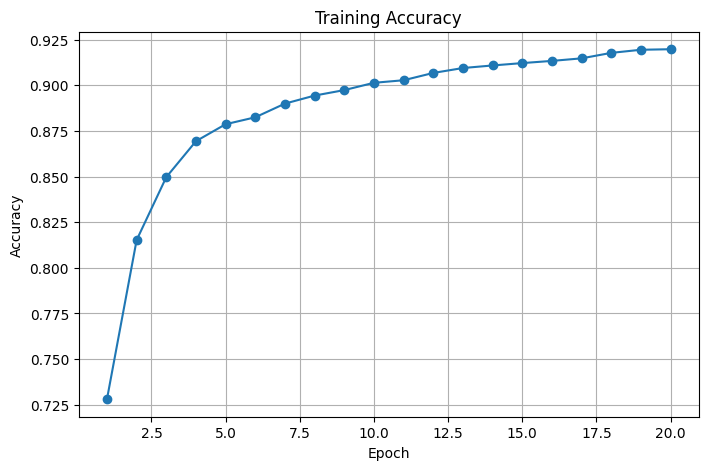

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    accuracy_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.grid(True)

plt.show()

After training, the model's performance is evaluated on the unseen test dataset. We use the `predict` function to get predictions for `X_test` and then calculate the `test_accuracy` using the `accuracy` function. The test accuracy is printed both as a decimal and as a percentage.

In [ ]:
test_predictions = predict(
    X_test,
    W1,
    b1,
    W2,
    b2
)

test_accuracy = accuracy(
    y_test,
    test_predictions
)

print(
    "Test Accuracy:",
    test_accuracy
)

print(
    "Test Accuracy (%):",
    test_accuracy * 100
)

Test Accuracy: 0.9095
Test Accuracy (%): 90.95


This cell creates and displays a Pandas DataFrame showing a comparison of the actual and predicted labels for the first 30 images in the test set. This provides a quick visual check of individual predictions.

In [ ]:
results = pd.DataFrame({
    "Actual": y_test[:30],
    "Predicted": test_predictions[:30]
})

results

,Actual,Predicted
0,7,7
1,2,2
2,1,1
3,0,0
4,4,4
5,1,1
6,4,4
7,9,9
8,5,6
9,9,9


A confusion matrix is a table that is often used to describe the performance of a classification model. This cell calculates and prints the confusion matrix for the test set, showing the number of correct and incorrect predictions for each digit class.

In [ ]:
confusion_matrix = np.zeros(
    (10, 10),
    dtype=int
)

for actual, predicted in zip(
    y_test,
    test_predictions
):

    confusion_matrix[
        actual,
        predicted
    ] += 1

print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[ 959    0    1    1    0    3    9    1    6    0]
 [   0 1106    2    3    0    3    4    1   16    0]
 [   7    5  903   18    7    1   17   18   45   11]
 [   5    0   22  914    1   26    2   11   19   10]
 [   1    5    6    0  878    0   14    3   12   63]
 [  14    4    4   33    6  762   15    7   38    9]
 [  13    3    8    2   16   17  895    1    3    0]
 [   1   19   31    5    6    0    0  925    3   38]
 [  11    7    8   28    8   18   11   11  852   20]
 [   9    7    2   13   29   11    1   28    8  901]]


This cell visualizes the confusion matrix as a heatmap. The intensity of the color at each cell `(i, j)` represents the number of times a digit `i` was predicted as digit `j`. A good model will have high values along the main diagonal.

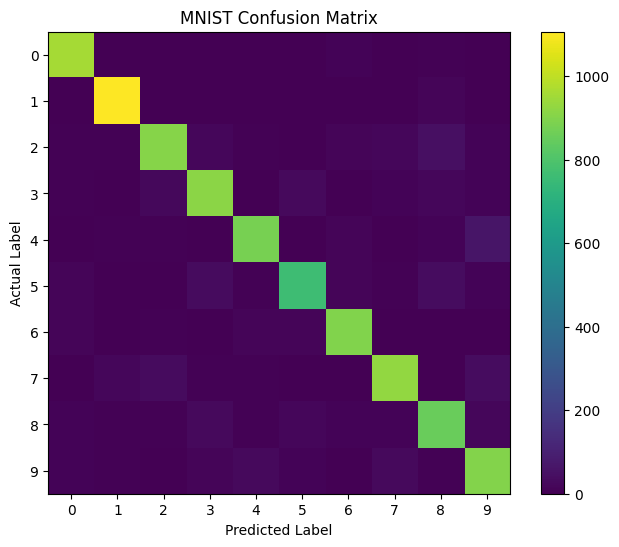

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(
    confusion_matrix
)

plt.title("MNIST Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

plt.show()

This cell provides a detailed look at the prediction for a single test image (at `index = 0`). It shows the actual digit, the predicted digit, and the probability distribution for each class, helping to understand the model's confidence in its prediction.

In [ ]:
index = 0

sample = X_test[index].reshape(1, -1)

_, _, _, probabilities = forward_pass(
    sample,
    W1,
    b1,
    W2,
    b2
)

prediction = np.argmax(
    probabilities
)

print("Actual Digit:", y_test[index])
print("Predicted Digit:", prediction)

print("\nClass Probabilities:")

for digit in range(10):

    print(
        f"Digit {digit}: "
        f"{probabilities[0][digit] * 100:.2f}%"
    )

Actual Digit: 7
Predicted Digit: 7

Class Probabilities:
Digit 0: 0.03%
Digit 1: 0.00%
Digit 2: 0.01%
Digit 3: 0.26%
Digit 4: 0.01%
Digit 5: 0.01%
Digit 6: 0.00%
Digit 7: 99.33%
Digit 8: 0.01%
Digit 9: 0.35%


This cell visualizes the individual test image (at `index = 0`) along with its actual and predicted labels, providing a direct visual confirmation of the model's classification for that specific example.

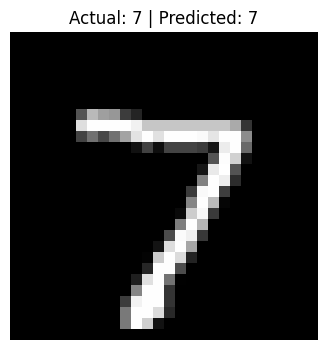

In [ ]:
index = 0

plt.figure(figsize=(4, 4))

plt.imshow(
    X_test[index].reshape(28, 28),
    cmap="gray"
)

plt.title(
    f"Actual: {y_test[index]} | "
    f"Predicted: {test_predictions[index]}"
)

plt.axis("off")

plt.show()

This cell displays a grid of the first 20 test images, along with their actual ('A') and predicted ('P') labels. This allows for a broader visual inspection of the model's performance across multiple samples and helps identify common misclassifications.

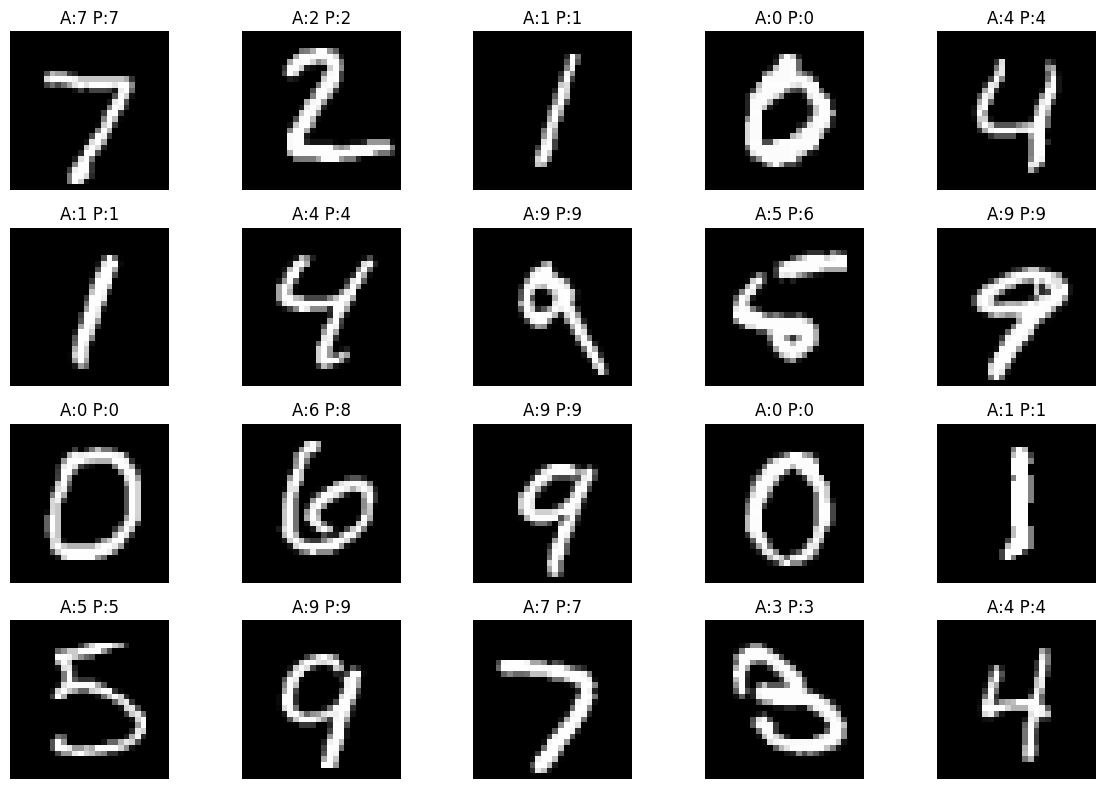

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(20):

    plt.subplot(4, 5, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"A:{y_test[i]} P:{test_predictions[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

This cell provides a comprehensive summary of the neural network model, including dataset details, network architecture, activation functions, loss function, optimization method, hyperparameters, and the final training and test accuracies. This consolidates all the important information about the model's setup and performance.

In [ ]:
print("=" * 60)
print("NEURAL NETWORK FROM SCRATCH - MNIST")
print("=" * 60)

print("Dataset: MNIST")

print("Training Samples Used:", len(X_train_small))
print("Testing Samples:", len(X_test))

print("Image Size: 28 x 28")
print("Input Neurons:", input_size)

print("Hidden Neurons:", hidden_size)
print("Output Neurons:", output_size)

print("Hidden Activation: ReLU")
print("Output Activation: Softmax")

print("Loss Function: Cross-Entropy")
print("Optimization: Mini-Batch Gradient Descent")

print("Learning Rate:", learning_rate)
print("Epochs:", epochs)
print("Batch Size:", batch_size)

print(
    f"\nFinal Training Accuracy: "
    f"{accuracy_history[-1] * 100:.2f}%"
)

print(
    f"Final Training Loss: "
    f"{loss_history[-1]:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print("=" * 60)

NEURAL NETWORK FROM SCRATCH - MNIST
Dataset: MNIST
Training Samples Used: 10000
Testing Samples: 10000
Image Size: 28 x 28
Input Neurons: 784
Hidden Neurons: 128
Output Neurons: 10
Hidden Activation: ReLU
Output Activation: Softmax
Loss Function: Cross-Entropy
Optimization: Mini-Batch Gradient Descent
Learning Rate: 0.01
Epochs: 20
Batch Size: 64

Final Training Accuracy: 91.98%
Final Training Loss: 0.2933
Test Accuracy: 90.95%


Finally, the trained model's weights and biases (`W1`, `b1`, `W2`, `b2`) are saved to a `.npz` file named `mnist_neural_network_weights.npz`. This allows the trained model to be loaded and used later without needing to retrain it.

In [ ]:
np.savez(
    "mnist_neural_network_weights.npz",
    W1=W1,
    b1=b1,
    W2=W2,
    b2=b2
)

print("Model weights saved successfully.")

Model weights saved successfully.


This cell demonstrates how to load the previously saved model weights from the `mnist_neural_network_weights.npz` file. The loaded weights (`W1_loaded`, `b1_loaded`, `W2_loaded`, `b2_loaded`) can then be used to reconstruct the trained neural network for inference or further analysis.

In [ ]:
loaded_model = np.load(
    "mnist_neural_network_weights.npz"
)

W1_loaded = loaded_model["W1"]
b1_loaded = loaded_model["b1"]

W2_loaded = loaded_model["W2"]
b2_loaded = loaded_model["b2"]

print("Weights loaded successfully.")

Weights loaded successfully.


Thank You

Submitted by :

202502110008   
Dhanashri Abhijit Shah
